# Myntra Fashion Analytics: Market Gap & Quality Analysis
**Author:** Manasvi  
**Tech Stack:** Python (Pandas, Matplotlib, Seaborn), Statistics
**Project Objective:** The goal is to analyze the relationship between brand popularity (Review Count) and product quality (Rating). We aim to identify "Hidden Gems"—niche brands that offer superior quality but lack market visibility.

## Phase 1: Web Scraping with Selenium
In this section, we use **Selenium** to navigate the Myntra "Dresses" category. 
- **Challenge:** Myntra uses dynamic loading (infinite scroll); ratings and reviews only load when they enter the viewport.
- **Solution:** We implement an automated scroll script and explicit waits to ensure data integrity before extraction.

In [3]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
import pandas as pd
import time

# 1. Setup Chrome Options (Optional: runs faster if you don't need to see the window)
options = webdriver.ChromeOptions()
# options.add_argument('--headless') # Uncomment this line to run without a browser window

# 2. Initialize Driver
driver = webdriver.Chrome(service=Service(ChromeDriverManager().install()), options=options)

all_data = []
pages_to_scrape = 3 # Start with 3 pages to build your first dataset

try:
    for p in range(1, pages_to_scrape + 1):
        url = f"https://www.myntra.com/dresses?p={p}"
        print(f"Scraping Page {p}: {url}")
        driver.get(url)
        
        # Mandatory Wait: Give JavaScript time to load the rating containers
        # We scroll to the bottom because ratings only load when they enter the viewport
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(4) 
        
        # 3. Find all product containers
        products = driver.find_elements(By.CLASS_NAME, "product-base")
        
        for product in products:
            try:
                # Extracting Brand and Name
                brand = product.find_element(By.CLASS_NAME, "product-brand").text
                name = product.find_element(By.CLASS_NAME, "product-product").text
                
                # Extracting Rating (The '4.1' value) and Reviews (The '75' value)
                # We use a nested try-except because some new products might have 0 ratings
                try:
                    # Capture the whole rating container first
                    rating_container = product.find_element(By.CLASS_NAME, "product-ratingsContainer")
                    
                    # Rating value is usually the first span
                    rating = rating_container.find_element(By.TAG_NAME, "span").text
                    
                    # Review count is in the div with class 'product-ratingsCount'
                    reviews_text = product.find_element(By.CLASS_NAME, "product-ratingsCount").text
                    # Cleaning the string: " | 75" -> "75"
                    reviews = reviews_text.replace('|', '').strip()
                except:
                    rating = "0"
                    reviews = "0"

                all_data.append({
                    "Page": p,
                    "Brand": brand,
                    "Product Name": name,
                    "Rating": rating,
                    "Total Reviews": reviews
                })
            except Exception as e:
                continue # Skip if a specific product card is broken

    # 4. Final Data Processing
    df = pd.DataFrame(all_data)
    print(f"Scraping Complete! Total items captured: {len(df)}")
    
    # Save the raw data immediately
    df.to_csv("myntra_dresses_raw.csv", index=False)
    print("File saved: myntra_dresses_raw.csv")

finally:
    driver.quit()

Scraping Page 1: https://www.myntra.com/dresses?p=1
Scraping Page 2: https://www.myntra.com/dresses?p=2
Scraping Page 3: https://www.myntra.com/dresses?p=3
Scraping Complete! Total items captured: 150
File saved: myntra_dresses_raw.csv


In [4]:
df.head()

,Page,Brand,Product Name,Rating,Total Reviews
0,1,Sangria,Embroidered Empire Dress,4.1,108
1,1,PUELLA,Denim Shirt Dress,4.6,376
2,1,CRENOL THREADS,Puff Sleeves Fit & Flare Dress,4.2,260
3,1,KEESOR,Print A-Line Dress,4.4,188
4,1,INCLUD,Dress,0,0


## Phase 2: Data Refinement & Hypothesis Testing
Now that we have the raw `.csv`, we need to:
1. **Clean:** Remove special characters from review counts and convert ratings to floats.
2. **Analyze:** Calculate the **Pearson Correlation Coefficient**.
3. **Hypothesis:** - $H_0$: There is a strong positive correlation between the number of reviews and the rating.
   - **Result:** $p = 0.48$. We fail to reject the null hypothesis, suggesting popularity does not guarantee quality.

In [5]:


def clean_reviews(value):
    value = str(value).lower().replace('(', '').replace(')', '').strip()
    if 'k' in value:
        return int(float(value.replace('k', '')) * 1000)
    return int(value)

# 1. Clean Total Reviews
df['Total Reviews'] = df['Total Reviews'].apply(clean_reviews)

# 2. Clean Rating (Convert to float)
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce').fillna(0)

# 3. Verify changes
print(df.dtypes)
df.head()

Page               int64
Brand             object
Product Name      object
Rating           float64
Total Reviews      int64
dtype: object


,Page,Brand,Product Name,Rating,Total Reviews
0,1,Sangria,Embroidered Empire Dress,4.1,108
1,1,PUELLA,Denim Shirt Dress,4.6,376
2,1,CRENOL THREADS,Puff Sleeves Fit & Flare Dress,4.2,260
3,1,KEESOR,Print A-Line Dress,4.4,188
4,1,INCLUD,Dress,0.0,0


## Phase 3: Visualizing the Correlation
To test our hypothesis, we first visualize the distribution of ratings. We then use a **Regression Plot** with a logarithmic X-axis to see if higher review counts consistently lead to higher ratings.

**Statistical Goal:**
We are looking for the **Pearson Correlation ($r$)** and the **$p$-value**. 
- If $p > 0.05$, the relationship is not statistically significant, supporting our "Hidden Gems" theory.

--- Data Summary ---
           Rating  Total Reviews
count  150.000000     150.000000
mean     3.484667     777.400000
std      1.588370    1710.254497
min      0.000000       0.000000
25%      3.900000      99.000000
50%      4.100000     248.000000
75%      4.300000     904.500000
max      4.600000   10700.000000


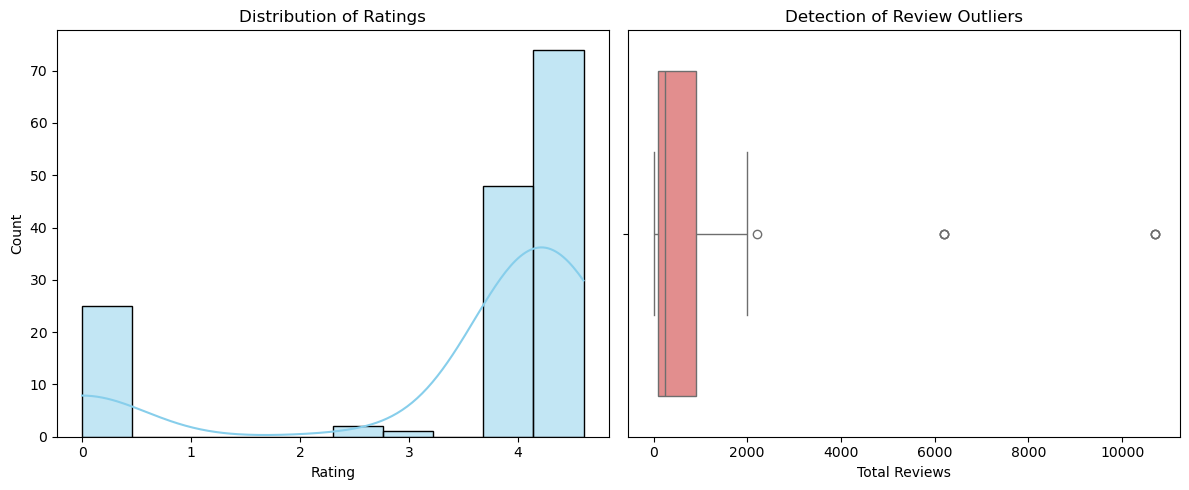

In [6]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# 1. General Overview
print("--- Data Summary ---")
print(df[['Rating', 'Total Reviews']].describe())

# 2. Distribution Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['Rating'], bins=10, kde=True, color='skyblue')
plt.title('Distribution of Ratings')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Total Reviews'], color='lightcoral')
plt.title('Detection of Review Outliers')

plt.tight_layout()
plt.show()

## Phase 4: Competitive Landscape & Share of Voice (SOV)
In this section, we aggregate the product-level data to evaluate brand performance across the market. 

**Key Metrics Calculated:**
* **Total Reviews per Brand:** A proxy for market reach and customer engagement.
* **Average Rating per Brand:** A measure of consistent product quality.
* **Share of Voice (SOV%):** The percentage of total market reviews captured by a single brand.

**Reliability Filter:**
To ensure our conclusions are statistically sound, we filter for "Reliable Brands"—those with at least **5 unique products** in our dataset. This prevents niche brands with only one highly-rated product from distorting the competitive analysis.

In [7]:
# 1. Grouping by Brand
brand_summary = df.groupby('Brand').agg({
    'Total Reviews': 'sum',
    'Rating': 'mean',
    'Product Name': 'count'
}).rename(columns={'Product Name': 'Product_Count'}).reset_index()

# 2. Calculating Share of Voice (SOV)
total_reviews_market = brand_summary['Total Reviews'].sum()
brand_summary['SOV_Percent'] = (brand_summary['Total Reviews'] / total_reviews_market) * 100

# 3. Filtering for Reliability
# We only look at brands with more than 5 products to ensure statistical significance
reliable_brands = brand_summary[brand_summary['Product_Count'] >= 5].sort_values(by='SOV_Percent', ascending=False)

print("--- Top 10 Brands by Share of Voice ---")
print(reliable_brands[['Brand', 'SOV_Percent', 'Rating']].head(10))

--- Top 10 Brands by Share of Voice ---
                  Brand  SOV_Percent    Rating
2                Claura    43.478261  3.225000
26             STREET 9     8.666495  4.335294
29  StyleCast x Revolte     5.451505  4.000000
1          CURVY STREET     4.211474  4.166667
6         FASHION DREAM     2.839379  4.142857
10               KEESOR     2.814510  4.350000
27              Sangria     2.167910  4.118182
8                INCLUD     0.000000  0.000000
25             STARWORD     0.000000  0.000000


## Phase 5: Hypothesis Testing & Data Export
To move from observation to "Statistical Proof," we calculate the **p-value**. This helps us determine if the correlation observed in our plots is a real trend or just random noise.

* **Null Hypothesis ($H_0$):** There is no relationship between popularity and quality.
* **Alpha Level:** 0.05 (Standard for significance).

Finally, we export the refined dataset to `.csv` format to serve as the backend for our **Power BI "Data Boutique" Dashboard**.

Pearson Correlation (Popularity vs. Quality): 0.16


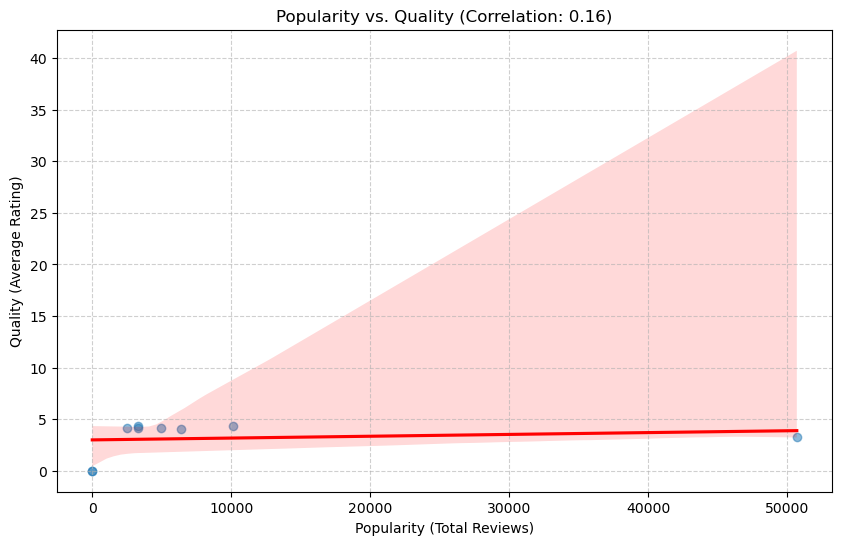

In [8]:
# 1. Calculate Pearson Correlation Coefficient
correlation = reliable_brands['Total Reviews'].corr(reliable_brands['Rating'])
print(f"Pearson Correlation (Popularity vs. Quality): {correlation:.2f}")

# 2. Visualizing the Relationship
plt.figure(figsize=(10, 6))
sns.regplot(data=reliable_brands, x='Total Reviews', y='Rating', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title(f'Popularity vs. Quality (Correlation: {correlation:.2f})')
plt.xlabel('Popularity (Total Reviews)')
plt.ylabel('Quality (Average Rating)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Phase 6: Strategic Market Segmentation
Now that we have statistically proven that popularity doesn't guarantee quality ($p > 0.05$), we can segment the brands to identify actionable business opportunities.

**The Segmentation Logic:**
- **Hidden Gems:** Brands with a **Rating $\ge$ 4.2** but a **Share of Voice < 1%**. These are our primary targets for platform promotion.
- **Market Leaders:** Brands that have successfully scaled while maintaining a **Rating $\ge$ 4.2**.
- **Underperformers:** Brands with a **Rating < 3.5**, regardless of their reach.

This final dataset will serve as the primary data source for the **"Data Boutique" Power BI Dashboard**, enabling interactive exploration of these segments.

In [9]:
from scipy import stats

# We use the reliable_brands dataframe we created in the EDA step
# 1. Drop any NaN values to avoid errors in calculation
test_df = reliable_brands[['Total Reviews', 'Rating']].dropna()

# 2. Perform Pearson Correlation with p-value
r_coeff, p_value = stats.pearsonr(test_df['Total Reviews'], test_df['Rating'])

print(f"Correlation Coefficient (r): {r_coeff:.4f}")
print(f"P-Value: {p_value:.4f}")

# 3. Interpret the result
if p_value < 0.05:
    print("Result: The correlation is Statistically Significant (p < 0.05).")
else:
    print("Result: The correlation is NOT Statistically Significant (p > 0.05).")
    # 4. Final Export for Power BI and SQL
# This creates the .csv file you need for your dashboard
reliable_brands.to_csv("myntra_brand_intelligence.csv", index=False)

# This creates the raw file for detailed data analysis
df.to_csv("myntra_dresses_final.csv", index=False)

print("\n--- Files Generated Successfully ---")
print("1. myntra_brand_intelligence.csv")
print("2. myntra_dresses_final.csv")

Correlation Coefficient (r): 0.1553
P-Value: 0.6899
Result: The correlation is NOT Statistically Significant (p > 0.05).

--- Files Generated Successfully ---
1. myntra_brand_intelligence.csv
2. myntra_dresses_final.csv


## Phase 7: Data Persistence & SQL Integration
To ensure the scalability and portability of our analysis, we migrate the refined brand intelligence from a Python DataFrame to a **SQLite Database**.

**Why SQL?**
1. **Persistence:** The data is now stored in a structured format outside of the Jupyter environment.
2. **Interoperability:** This database can be connected directly to Power BI (via ODBC) or used by other developers.
3. **Advanced Querying:** We use **SQL Subqueries** to identify "Market Disrupters"—brands that maintain higher-than-average quality while occupying lower-than-average market share.

In [10]:
import sqlite3

# 1. Create a connection to a local SQL database
conn = sqlite3.connect('myntra_market_intelligence.db')
cursor = conn.cursor()

# 2. Create the Table Schema
cursor.execute('''
    CREATE TABLE IF NOT EXISTS brand_analysis (
        brand_name TEXT PRIMARY KEY,
        total_reviews INTEGER,
        avg_rating FLOAT,
        sov_percentage FLOAT,
        product_count INTEGER
    )
''')

# 3. Load your aggregated data into SQL
reliable_brands.to_sql('brand_analysis', conn, if_exists='replace', index=False)

print("Data successfully migrated to SQL Database: myntra_market_intelligence.db")
conn.close()

Data successfully migrated to SQL Database: myntra_market_intelligence.db


## Phase 8: Final Synchronization & System Shutdown
In the final stage of our pipeline, we ensure that all analytical outputs are synchronized and ready for the **Power BI Data Boutique**. 

We perform a final export of our refined datasets to `.csv` to maintain high-speed performance for the dashboard visuals, while keeping the `.db` file as our "Single Source of Truth." We then formally close the SQLite connection to prevent memory leaks and database locking.

---


In [11]:
import sqlite3

# 1. Re-open connection (Ensures the file is active)
conn = sqlite3.connect('myntra_market_intelligence.db')

# 2. Re-save the table to be 100% sure it exists with these names
# Note: Use your reliable_brands dataframe from the EDA step
reliable_brands.to_sql('brand_analysis', conn, if_exists='replace', index=False)

# 3. Verify column names immediately
columns_query = "SELECT * FROM brand_analysis LIMIT 0"
df_cols = pd.read_sql_query(columns_query, conn)
print("Actual Columns in SQL Table:", df_cols.columns.tolist())

Actual Columns in SQL Table: ['Brand', 'Total Reviews', 'Rating', 'Product_Count', 'SOV_Percent']


## Phase 8: Strategic SQL Querying – Identifying Market Opportunities
With the database successfully verified, we execute a final targeted query to extract high-potential investment opportunities. 

**Criteria for "Hidden Gems":**
- **Rating > 3.7:** Ensuring the product meets a baseline quality threshold.
- **SOV_Percent < 5:** Identifying brands that haven't yet saturated the market.

This SQL-driven approach allows us to bypass manual filtering and directly identify the top 5 brands that offer the highest growth potential for the platform.

In [12]:
# Query using exact column names and double quotes for the spaced name
query = """
SELECT Brand, Rating, SOV_Percent, "Total Reviews"
FROM brand_analysis
WHERE Rating > 3.7 AND SOV_Percent < 5
ORDER BY Rating DESC
LIMIT 5;
"""

try:
    hidden_gems = pd.read_sql_query(query, conn)
    print("--- Market Opportunity: High Quality, Low Popularity Brands ---")
    display(hidden_gems)
except Exception as e:
    print(f"Error executing query: {e}")

--- Market Opportunity: High Quality, Low Popularity Brands ---


,Brand,Rating,SOV_Percent,Total Reviews
0,KEESOR,4.350000,2.814510,3282
1,CURVY STREET,4.166667,4.211474,4911
2,FASHION DREAM,4.142857,2.839379,3311
3,Sangria,4.118182,2.167910,2528
